cell 1

In [25]:
!pip install streamlit torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 111.2 MB/s eta 0:00:0000:01


cell 2

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import streamlit as st
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


cell 3

In [28]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x

class MaskedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.patch_embed = PatchEmbed(img_size=224, patch_size=16, embed_dim=768)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, 768))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, 768))
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=768, nhead=12, dim_feedforward=3072, activation='gelu', batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=12) 
        
        self.decoder_embed = nn.Linear(768, 384) 
        self.mask_token = nn.Parameter(torch.zeros(1, 1, 384)) 
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, 384))
        
        decoder_layer = nn.TransformerEncoderLayer(d_model=384, nhead=6, dim_feedforward=1536, activation='gelu', batch_first=True)
        self.decoder = nn.TransformerEncoder(decoder_layer, num_layers=12)
        
        self.decoder_pred = nn.Linear(384, 16**2 * 3) 

    def random_masking(self, x, mask_ratio=0.75):
        B, N, D = x.shape
        len_keep = int(N * (1 - mask_ratio))
        
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        
        mask = torch.ones([B, N], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        return x_masked, mask, ids_restore

    def forward_encoder(self, x, mask_ratio):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        
        x, mask, ids_restore = self.random_masking(x, mask_ratio)
        
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        
        x = self.encoder(x)
        return x, mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))
        
        x = torch.cat([x[:, :1, :], x_], dim=1)
        x = x + self.decoder_pos_embed
        
        x = self.decoder(x)
        x = self.decoder_pred(x)
        
        x = x[:, 1:, :]
        return x

    def forward(self, imgs, mask_ratio=0.75):
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        return pred, mask

model = MaskedAutoencoder().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} (~108M combined)")

Model parameters: 107,757,696 (~108M combined)


cell 4

In [29]:
dataset_path = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train"
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = ImageFolder(dataset_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)

cell 5 training

Starting training for 40 epochs with 5-epoch LR warmup...


/tmp/ipykernel_55/1456302639.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_55/1456302639.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/40 | LR: 0.000000 | Loss: 1.1049
Epoch 2/40 | LR: 0.000030 | Loss: 0.8018
Epoch 3/40 | LR: 0.000060 | Loss: 0.7807
Epoch 4/40 | LR: 0.000090 | Loss: 0.7359
Epoch 5/40 | LR: 0.000120 | Loss: 0.7078
Epoch 6/40 | LR: 0.000150 | Loss: 0.6731
Epoch 7/40 | LR: 0.000150 | Loss: 0.5691
Epoch 8/40 | LR: 0.000149 | Loss: 0.4755
Epoch 9/40 | LR: 0.000147 | Loss: 0.4446
Epoch 10/40 | LR: 0.000145 | Loss: 0.4274
Epoch 11/40 | LR: 0.000143 | Loss: 0.4192
Epoch 12/40 | LR: 0.000139 | Loss: 0.4091
Epoch 13/40 | LR: 0.000136 | Loss: 0.4037
Epoch 14/40 | LR: 0.000131 | Loss: 0.3974
Epoch 15/40 | LR: 0.000127 | Loss: 0.3911
Epoch 16/40 | LR: 0.000122 | Loss: 0.3877
Epoch 17/40 | LR: 0.000116 | Loss: 0.3836
Epoch 18/40 | LR: 0.000111 | Loss: 0.3802
Epoch 19/40 | LR: 0.000104 | Loss: 0.3773
Epoch 20/40 | LR: 0.000098 | Loss: 0.3750
Epoch 21/40 | LR: 0.000092 | Loss: 0.3726
Epoch 22/40 | LR: 0.000085 | Loss: 0.3709
Epoch 23/40 | LR: 0.000078 | Loss: 0.3685
Epoch 24/40 | LR: 0.000072 | Loss: 0.3667
E

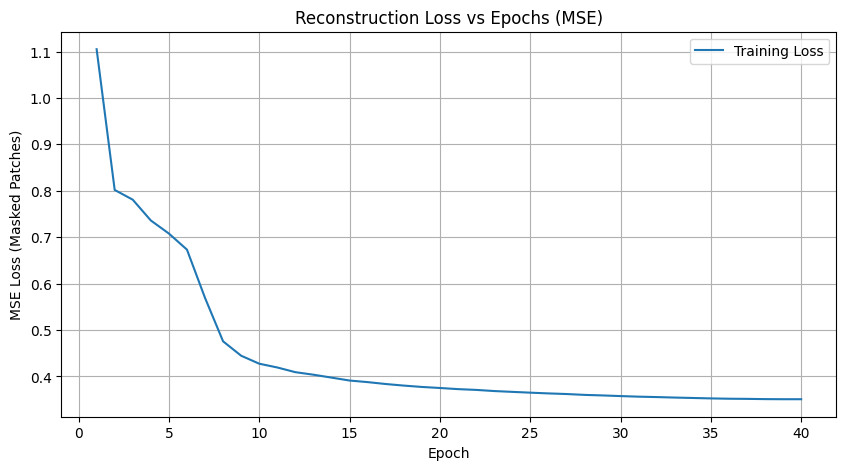

In [5]:
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast


num_epochs = 40
warmup_epochs = 5
base_lr = 1.5e-4  


optimizer = optim.AdamW(model.parameters(), lr=base_lr, weight_decay=0.05) 


warmup_scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=1e-3, total_iters=warmup_epochs)

cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs - warmup_epochs)

scheduler = optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_epochs])

scaler = GradScaler()

def patchify(imgs):
    p = 16
    assert imgs.shape[2] == imgs.shape[3] and imgs.shape[2] % p == 0
    h = w = imgs.shape[2] // p
    x = imgs.reshape(shape=(imgs.shape[0], 3, h, p, w, p))
    x = torch.einsum('nchpwq->nhwpqc', x)
    x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * 3))
    return x

loss_history = []
print(f"Starting training for {num_epochs} epochs with {warmup_epochs}-epoch LR warmup...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
   
    current_lr = optimizer.param_groups[0]['lr']
    
    for imgs, _ in dataloader:
        imgs = imgs.to(device)
        
       
        target = patchify(imgs)
        
       
        mean = target.mean(dim=-1, keepdim=True)
        var = target.var(dim=-1, keepdim=True)
        target_norm = (target - mean) / (var + 1.e-6)**.5
        
        optimizer.zero_grad()
        
        
        with autocast():
            pred, mask = model(imgs, mask_ratio=0.75)
            
          
            loss = (pred - target_norm) ** 2
            loss = loss.mean(dim=-1) 
            loss = (loss * mask).sum() / mask.sum() 
            
        scaler.scale(loss).backward()
        
       
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        
    scheduler.step()
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    
   
    print(f"Epoch {epoch+1}/{num_epochs} | LR: {current_lr:.6f} | Loss: {avg_loss:.4f}")


plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), loss_history, label='Training Loss')
plt.title("Reconstruction Loss vs Epochs (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (Masked Patches)")
plt.legend()
plt.grid(True)
plt.show()

cell 6 evaluation

In [33]:
import torch
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

def patchify(imgs):
    p = 16 
    h = w = imgs.shape[2] // p
    x = imgs.reshape(shape=(imgs.shape[0], 3, h, p, w, p))
    x = torch.einsum('nchpwq->nhwpqc', x)
    x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * 3))
    return x

def unpatchify(x):
    p = 16
    h = w = int(x.shape[1]**0.5)
    x = x.reshape(shape=(x.shape[0], h, w, p, p, 3))
    x = torch.einsum('nhwpqc->nchpwq', x)
    imgs = x.reshape(shape=(x.shape[0], 3, h * p, h * p))
    return imgs

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

model.eval()
eval_imgs, _ = next(iter(dataloader))
eval_imgs = eval_imgs.to(device)

with torch.no_grad():
    pred, mask = model(eval_imgs, mask_ratio=0.75)

target = patchify(eval_imgs)


mean_patch = target.mean(dim=-1, keepdim=True)
var_patch = target.var(dim=-1, keepdim=True)

pred_unnorm = pred * (var_patch + 1.e-6)**.5 + mean_patch

mask_vis = mask.unsqueeze(-1).repeat(1, 1, 16**2 * 3)

recon_patches = target * (1 - mask_vis) + pred_unnorm * mask_vis
recon_imgs = unpatchify(recon_patches)

mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

eval_imgs_denorm = torch.clamp(eval_imgs * std + mean, 0, 1)
recon_imgs_denorm = torch.clamp(recon_imgs * std + mean, 0, 1)

psnr_score = psnr_metric(recon_imgs_denorm, eval_imgs_denorm)
ssim_score = ssim_metric(recon_imgs_denorm, eval_imgs_denorm)

print("--- Quantitative Evaluation ---")
print(f"Average PSNR: {psnr_score.item():.2f} dB")
print(f"Average SSIM: {ssim_score.item():.4f}")

--- Quantitative Evaluation ---
Average PSNR: 17.24 dB
Average SSIM: 0.3839
